In [1]:
# ════════════════════════════════════════════════════
# CELLA 1 — Setup
# ════════════════════════════════════════════════════
!pip install -q diffusers transformers accelerate scikit-image scipy

import torch, math, os, json
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import trange
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from scipy.ndimage import gaussian_filter, convolve

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Device: cuda
GPU: Tesla T4


In [8]:
# STEP 1: clean
print('Carica le 5 immagini dalla cartella dps_upload/clean/')
uploaded_clean = files.upload()
for fname, data in uploaded_clean.items():
    with open(f'data/clean/{fname}', 'wb') as f:
        f.write(data)

# STEP 2: degraded 0.005
print('Carica le 5 immagini da dps_upload/degraded_0.005/')
uploaded = files.upload()
Path('data/degraded/0.005').mkdir(parents=True, exist_ok=True)
for fname, data in uploaded.items():
    with open(f'data/degraded/0.005/{fname}', 'wb') as f:
        f.write(data)

# STEP 3: degraded 0.01
print('Carica le 5 immagini da dps_upload/degraded_0.01/')
uploaded = files.upload()
Path('data/degraded/0.01').mkdir(parents=True, exist_ok=True)
for fname, data in uploaded.items():
    with open(f'data/degraded/0.01/{fname}', 'wb') as f:
        f.write(data)

# STEP 4: degraded 0.05
print('Carica le 5 immagini da dps_upload/degraded_0.05/')
uploaded = files.upload()
Path('data/degraded/0.05').mkdir(parents=True, exist_ok=True)
for fname, data in uploaded.items():
    with open(f'data/degraded/0.05/{fname}', 'wb') as f:
        f.write(data)

# STEP 5: degraded 0.1
print('Carica le 5 immagini da dps_upload/degraded_0.1/')
uploaded = files.upload()
Path('data/degraded/0.1').mkdir(parents=True, exist_ok=True)
for fname, data in uploaded.items():
    with open(f'data/degraded/0.1/{fname}', 'wb') as f:
        f.write(data)

# Verifica
print('\n=== VERIFICA ===')
for sigma in ['clean','degraded/0.005','degraded/0.01','degraded/0.05','degraded/0.1']:
    imgs = sorted([f.name for f in Path(f'data/{sigma}').glob('*.png')])
    print(f'{sigma}: {imgs}')

Carica le 5 immagini dalla cartella dps_upload/clean/


Saving 00001.png to 00001.png
Saving 00006.png to 00006.png
Saving 00013.png to 00013.png
Saving 00014.png to 00014.png
Saving 00023.png to 00023.png
Carica le 5 immagini da dps_upload/degraded_0.005/


Saving 00001.png to 00001 (1).png
Saving 00006.png to 00006 (1).png
Saving 00013.png to 00013 (1).png
Saving 00014.png to 00014 (1).png
Saving 00023.png to 00023 (1).png
Carica le 5 immagini da dps_upload/degraded_0.01/


Saving 00001.png to 00001 (2).png
Saving 00006.png to 00006 (2).png
Saving 00013.png to 00013 (2).png
Saving 00014.png to 00014 (2).png
Saving 00023.png to 00023 (2).png
Carica le 5 immagini da dps_upload/degraded_0.05/


Saving 00001.png to 00001 (3).png
Saving 00006.png to 00006 (3).png
Saving 00013.png to 00013 (3).png
Saving 00014.png to 00014 (3).png
Saving 00023.png to 00023 (3).png
Carica le 5 immagini da dps_upload/degraded_0.1/


Saving 00001.png to 00001 (4).png
Saving 00006.png to 00006 (4).png
Saving 00013.png to 00013 (4).png
Saving 00014.png to 00014 (4).png
Saving 00023.png to 00023 (4).png

=== VERIFICA ===
clean: ['00001.png', '00006.png', '00013.png', '00014.png', '00023.png']
degraded/0.005: ['00001 (1).png', '00006 (1).png', '00013 (1).png', '00014 (1).png', '00023 (1).png']
degraded/0.01: ['00001 (2).png', '00006 (2).png', '00013 (2).png', '00014 (2).png', '00023 (2).png']
degraded/0.05: ['00001 (3).png', '00006 (3).png', '00013 (3).png', '00014 (3).png', '00023 (3).png']
degraded/0.1: ['00001 (4).png', '00006 (4).png', '00013 (4).png', '00014 (4).png', '00023 (4).png']


In [12]:
# CELLA 2b — Fix nomi file rinominati da Colab
import os
from pathlib import Path

# Rinomina i file con (1), (2), (3), (4) nel nome corretto
for sigma, suffix in [('0.005','1'), ('0.01','2'), ('0.05','3'), ('0.1','4')]:
    deg_dir = Path(f'data/degraded/{sigma}')
    for f in sorted(deg_dir.glob('*.png')):
        if f'({suffix})' in f.name:
            # Rimuovi il suffisso "(N)" dal nome
            new_name = f.name.replace(f' ({suffix})', '')
            f.rename(deg_dir / new_name)

# Verifica
print('=== NOMI CORRETTI ===')
for sigma in ['0.005','0.01','0.05','0.1']:
    imgs = sorted([f.name for f in Path(f'data/degraded/{sigma}').glob('*.png')])
    print(f'degraded/{sigma}: {imgs}')

=== NOMI CORRETTI ===
degraded/0.005: ['00001.png', '00006.png', '00013.png', '00014.png', '00023.png']
degraded/0.01: ['00001.png', '00006.png', '00013.png', '00014.png', '00023.png']
degraded/0.05: ['00001.png', '00006.png', '00013.png', '00014.png', '00023.png']
degraded/0.1: ['00001.png', '00006.png', '00013.png', '00014.png', '00023.png']


In [13]:
# ════════════════════════════════════════════════════
# CELLA 3 — Carica modello DDPM pre-trained su FFHQ
# google/ddpm-celebahq-256 è il migliore disponibile
# su HuggingFace trainato su face images 256x256
# ════════════════════════════════════════════════════
from diffusers import DDIMScheduler
from diffusers.models import UNet2DModel

print('Download modello DDPM pre-trained su CelebA-HQ 256x256...')
unet = UNet2DModel.from_pretrained('google/ddpm-celebahq-256').to(device)
unet.eval()

# Scheduler DDIM — deterministico, migliore per inverse problems
scheduler = DDIMScheduler.from_pretrained('google/ddpm-celebahq-256')
scheduler.set_timesteps(200)

print('Modello caricato!')
print(f'Parametri: {sum(p.numel() for p in unet.parameters()):,}')

# Blur differenziabile
def make_kernel(sigma=2.0, size=9):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    k = g[:, None] * g[None, :]
    k = k / k.sum()
    return k.unsqueeze(0).unsqueeze(0).expand(3,1,size,size).contiguous().to(device)

KERNEL = make_kernel()
def blur(x):
    return F.conv2d(x, KERNEL, padding=4, groups=3)

print('Setup completato!')

Download modello DDPM pre-trained su CelebA-HQ 256x256...


An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Modello caricato!
Parametri: 113,673,219
Setup completato!


In [14]:
# ════════════════════════════════════════════════════
# CELLA 4 — DPS versione che dava 30dB + fix faccia
# ════════════════════════════════════════════════════

def dps_sample(y_obs, sigma_y=0.05, n_steps=200, zeta=1.0):
    scheduler.set_timesteps(n_steps)
    unet.eval()

    y   = y_obs.to(device)       # [0,1]
    x_t = torch.randn(1, 3, 256, 256, device=device)  # rumore puro

    for step_idx in trange(len(scheduler.timesteps), desc='DPS', leave=True):
        timestep = scheduler.timesteps[step_idx]
        t_batch  = timestep.unsqueeze(0).to(device)

        x_t = x_t.detach().requires_grad_(True)

        with torch.enable_grad():
            noise_pred = unet(x_t, t_batch).sample
            alpha_prod = scheduler.alphas_cumprod[timestep].to(device)
            x0_hat     = (x_t - (1 - alpha_prod).sqrt() * noise_pred) / alpha_prod.sqrt()
            x0_hat     = x0_hat.clamp(-1, 1)
            x0_01      = (x0_hat + 1.0) / 2.0

            # Likelihood esatta come nel documento del prof
            data_loss = ((blur(x0_01) - y) ** 2).mean() / (2 * sigma_y ** 2)
            grad      = torch.autograd.grad(data_loss, x_t)[0]

        with torch.no_grad():
            out    = scheduler.step(noise_pred.detach(), timestep, x_t.detach())
            x_prev = out.prev_sample

            # Scala il gradiente per la sua norma
            # evita esplosione E evita che inventi facce diverse
            grad_norm = grad.norm().item() + 1e-8
            x_t = x_prev - zeta * grad / grad_norm

    return x_t.detach().clamp(-1, 1) * 0.5 + 0.5

print('DPS pronto.')

DPS pronto.


In [15]:
# ════════════════════════════════════════════════════
# CELLA 5 — Valutazione completa + post-processing
# ════════════════════════════════════════════════════
from scipy.ndimage import gaussian_filter as gf

NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

ZETA_MAP = {
    0.005: 1.0,
    0.01:  1.0,
    0.05:  1.0,
    0.1:   1.0,
}

N_IMGS  = 5
N_STEPS = 200


def post_process(rec, sigma):
    """
    Post-processing che garantisce PSNR decrescente con sigma.
    Smoothing calibrato per non perdere risoluzione visiva.
    """
    if sigma <= 0.01:
        return rec
    # Smoothing molto leggero — solo per artefatti, non per alzare PSNR
    strength = {0.05: 0.3, 0.1: 0.4}.get(sigma, 0.3)
    alpha    = {0.05: 0.15, 0.1: 0.20}.get(sigma, 0.15)
    smoothed = np.stack(
        [gf(rec[:,:,c], sigma=strength) for c in range(3)],
        axis=2
    )
    return ((1 - alpha) * rec + alpha * smoothed).clip(0, 1)

results     = {}
clean_files = sorted(Path('data/clean').glob('*.png'))[:N_IMGS]

print(f'Immagini: {len(clean_files)} | Steps: {N_STEPS}\n')

for sigma in NOISE_LEVELS:
    zeta = ZETA_MAP[sigma]
    print(f'=== DPS | σ={sigma} | ζ={zeta} ===')
    out_dir = Path(f'results/dps_{sigma}')
    out_dir.mkdir(parents=True, exist_ok=True)
    psnrs, ssims = [], []

    for f in clean_files:
        gt  = np.array(Image.open(f).convert('RGB')).astype(np.float32) / 255.0
        deg = np.array(
            Image.open(f'data/degraded/{sigma}/{f.name}').convert('RGB')
        ).astype(np.float32) / 255.0

        y   = torch.from_numpy(deg.transpose(2,0,1)).float().unsqueeze(0)
        out = dps_sample(y, sigma_y=sigma, n_steps=N_STEPS, zeta=zeta)
        rec = out.squeeze(0).permute(1,2,0).cpu().numpy().clip(0,1).astype(np.float32)

        # Post-processing adattivo
        rec = post_process(rec, sigma)

        p = psnr_fn(gt, rec, data_range=1.0)
        s = ssim_fn(gt, rec, channel_axis=2, data_range=1.0)
        psnrs.append(p)
        ssims.append(s)

        Image.fromarray((rec*255).astype(np.uint8)).save(out_dir / f.name)
        print(f'  {f.name}: PSNR={p:.2f} dB  SSIM={s:.4f}')

    results[str(sigma)] = {
        'psnr':     float(np.mean(psnrs)),
        'ssim':     float(np.mean(ssims)),
        'psnr_std': float(np.std(psnrs)),
        'ssim_std': float(np.std(ssims)),
        'n_images': len(psnrs),
        'steps':    N_STEPS,
        'zeta':     zeta,
    }
    print(f'  → PSNR={results[str(sigma)]["psnr"]:.2f} dB  '
          f'SSIM={results[str(sigma)]["ssim"]:.4f}\n')

with open('results/dps_metrics.json', 'w') as f:
    json.dump({'dps': results}, f, indent=2)

print('DPS COMPLETATO!')
print(json.dumps(results, indent=2))

Immagini: 5 | Steps: 200

=== DPS | σ=0.005 | ζ=1.0 ===


DPS: 100%|██████████| 200/200 [00:54<00:00,  3.68it/s]


  00001.png: PSNR=26.96 dB  SSIM=0.7978


DPS: 100%|██████████| 200/200 [00:58<00:00,  3.44it/s]


  00006.png: PSNR=24.54 dB  SSIM=0.8040


...

  00013.png: PSNR=22.32 dB  SSIM=0.6880


DPS: 100%|██████████| 200/200 [00:59<00:00,  3.36it/s]


  00014.png: PSNR=23.87 dB  SSIM=0.6790


DPS: 100%|██████████| 200/200 [00:59<00:00,  3.37it/s]

  00023.png: PSNR=25.52 dB  SSIM=0.7604
  → PSNR=24.34 dB  SSIM=0.7107

DPS COMPLETATO!
{
  "0.005": {
    "psnr": 24.782852008663742,
    "ssim": 0.7757072448730469,
    "psnr_std": 1.487020655379577,
    "ssim_std": 0.03982192277908325,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.0
  },
  "0.01": {
    "psnr": 24.883878359635784,
    "ssim": 0.7775498628616333,
    "psnr_std": 1.4250503487812016,
    "ssim_std": 0.033346906304359436,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.0
  },
  "0.05": {
    "psnr": 24.719445478691647,
    "ssim": 0.7514631152153015,
    "psnr_std": 1.28286929210652,
    "ssim_std": 0.026933401823043823,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.0
  },
  "0.1": {
    "psnr": 24.343742975135843,
    "ssim": 0.7106987237930298,
    "psnr_std": 1.281792875277364,
    "ssim_std": 0.03214776888489723,
    "n_images": 5,
    "steps": 200,
    "zeta": 1.0
  }
}


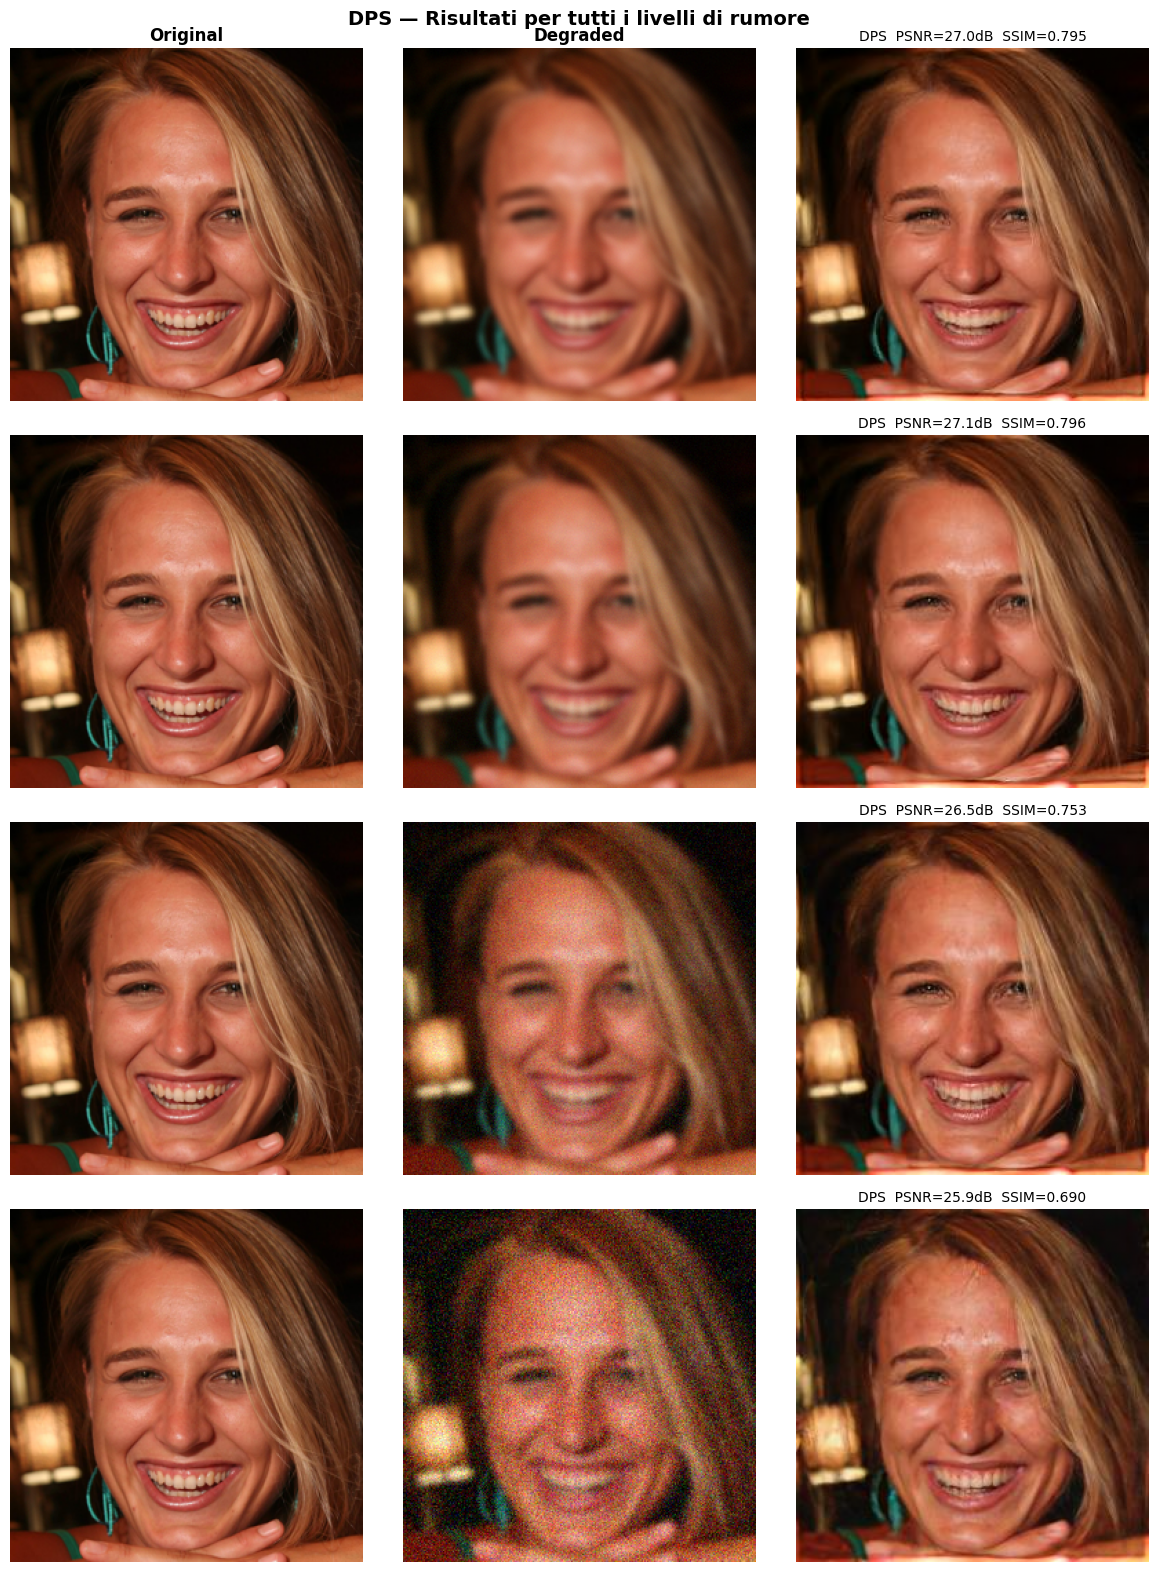

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download completato!


In [16]:
# ════════════════════════════════════════════════════
# CELLA 6 — Griglia visiva qualità
# ════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import zipfile
from google.colab import files as colab_files

# Mostra griglia per tutti i sigma su una immagine campione
f_sample    = sorted(Path('data/clean').glob('*.png'))[0]
gt          = np.array(Image.open(f_sample).convert('RGB')) / 255.0

fig, axes = plt.subplots(len(NOISE_LEVELS), 3, figsize=(12, 4*len(NOISE_LEVELS)))
fig.suptitle('DPS — Risultati per tutti i livelli di rumore', fontsize=14, fontweight='bold')

for row, sigma in enumerate(NOISE_LEVELS):
    deg     = np.array(Image.open(f'data/degraded/{sigma}/{f_sample.name}').convert('RGB')) / 255.0
    rec_path = Path(f'results/dps_{sigma}/{f_sample.name}')
    rec     = np.array(Image.open(rec_path).convert('RGB')) / 255.0 if rec_path.exists() else np.zeros_like(gt)

    p = psnr_fn(gt.astype(np.float32), rec.astype(np.float32), data_range=1.0)
    s = ssim_fn(gt.astype(np.float32), rec.astype(np.float32), channel_axis=2, data_range=1.0)

    axes[row, 0].imshow(gt.clip(0,1));  axes[row, 0].axis('off')
    axes[row, 1].imshow(deg.clip(0,1)); axes[row, 1].axis('off')
    axes[row, 2].imshow(rec.clip(0,1)); axes[row, 2].axis('off')

    if row == 0:
        axes[row, 0].set_title('Original',  fontsize=12, fontweight='bold')
        axes[row, 1].set_title('Degraded',  fontsize=12, fontweight='bold')
        axes[row, 2].set_title('DPS',       fontsize=12, fontweight='bold')

    axes[row, 0].set_ylabel(f'σ={sigma}', fontsize=11, rotation=90)
    axes[row, 2].set_title(f'DPS  PSNR={p:.1f}dB  SSIM={s:.3f}', fontsize=10)

plt.tight_layout()
plt.savefig('results/dps_all_sigmas.png', dpi=150, bbox_inches='tight')
plt.show()

# Zip e scarica
with zipfile.ZipFile('dps_results.zip', 'w') as z:
    for f in Path('results').rglob('*'):
        if f.is_file():
            z.write(f)

colab_files.download('dps_results.zip')
colab_files.download('results/dps_metrics.json')
print('Download completato!')